In [12]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
dataset_root = r"E:/Studies/Self/CCTV-Threat-Detection/Data/Smart-City-CCTV-Violence-Detection-Dataset (SCVD)\SCVD_converted"

train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

classes = ["Normal", "Violence", "Weaponized"]
print("Classes:", classes)
print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Classes: ['Normal', 'Violence', 'Weaponized']
Train classes: ['Normal', 'Violence', 'Weaponized']
Test classes: ['Normal', 'Violence', 'Weaponized']


In [14]:
class VideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, frames_per_clip=32):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(class_dir):
                if fname.endswith(".avi"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.frames_per_clip and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()

        # Pad if fewer frames
        while len(frames) < self.frames_per_clip:
            frames.append(torch.zeros_like(frames[0]))

        video_tensor = torch.stack(frames)  # shape: (T, C, H, W)
        return video_tensor, label

In [15]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = VideoDataset(train_dir, classes, transform, frames_per_clip=32)
test_dataset = VideoDataset(test_dir, classes, transform, frames_per_clip=32)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 399
Test samples: 82


In [16]:
#Model (ResNet50 + LSTM hybrid)
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
base_model = resnet50(weights=weights)
base_model.fc = nn.Linear(base_model.fc.in_features, 128)

class ViolenceClassifier(nn.Module):
    def __init__(self, base_model, num_classes=3):
        super(ViolenceClassifier, self).__init__()
        self.resnet = base_model
        self.lstm = nn.LSTM(128, 64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.resnet(x)
        features = features.view(B, T, -1)
        lstm_out, _ = self.lstm(features)
        out = self.fc(lstm_out[:, -1, :])
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViolenceClassifier(base_model, num_classes=len(classes)).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\risha/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 11.8MB/s]


In [17]:
weights = torch.tensor([1.0, 3.0, 2.0]).to(device)  # Normal, Violence, Weaponized
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

In [18]:
epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step(total_loss/len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/30, Loss: 1.0523
Epoch 2/30, Loss: 0.8004
Epoch 3/30, Loss: 0.4799
Epoch 4/30, Loss: 0.3146
Epoch 5/30, Loss: 0.2640
Epoch 6/30, Loss: 0.1409
Epoch 7/30, Loss: 0.1511
Epoch 8/30, Loss: 0.1107
Epoch 9/30, Loss: 0.0644
Epoch 10/30, Loss: 0.0613
Epoch 11/30, Loss: 0.1700
Epoch 12/30, Loss: 0.1060
Epoch 13/30, Loss: 0.0439
Epoch 14/30, Loss: 0.0290
Epoch 15/30, Loss: 0.0489
Epoch 16/30, Loss: 0.0484
Epoch 17/30, Loss: 0.0197
Epoch 18/30, Loss: 0.0255
Epoch 19/30, Loss: 0.0202
Epoch 20/30, Loss: 0.0072
Epoch 21/30, Loss: 0.0080
Epoch 22/30, Loss: 0.0119
Epoch 23/30, Loss: 0.0140
Epoch 24/30, Loss: 0.0336
Epoch 25/30, Loss: 0.0320
Epoch 26/30, Loss: 0.0086
Epoch 27/30, Loss: 0.0138
Epoch 28/30, Loss: 0.0074
Epoch 29/30, Loss: 0.0089
Epoch 30/30, Loss: 0.0057


              precision    recall  f1-score   support

      Normal       0.53      0.20      0.29        46
    Violence       0.27      0.33      0.30        12
  Weaponized       0.34      0.71      0.46        24

    accuracy                           0.37        82
   macro avg       0.38      0.41      0.35        82
weighted avg       0.44      0.37      0.34        82



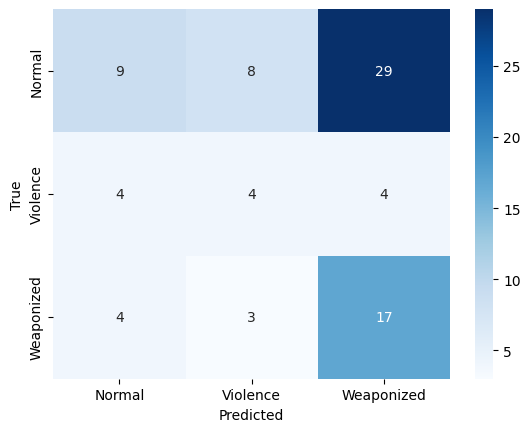

In [19]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()